In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

c:\Users\Zaheer jk\AppData\Local\anaconda3\envs\ai-ml\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [13]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATASET_DIR="../DATA"
IMG_HEIGHT=224
IMG_WIDTH=224
BATCH_SIZE=32
SEED=42

In [3]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='training',
    image_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed =SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [6]:
validation_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    image_size=(IMG_HEIGHT,IMG_WIDTH),
    subset='validation',
    batch_size=BATCH_SIZE,
    seed =SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [7]:
class_names=train_dataset.class_names
num_classes=len(class_names)

In [8]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [9]:
num_classes

6

## Base Model (CNN2D)

In [14]:
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255,input_shape=(IMG_HEIGHT,IMG_WIDTH,3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))


# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Flattening
model.add(tf.keras.layers.Flatten())


#FCL
model.add(tf.keras.layers.Dense(128,activation='relu'))

#output layer
model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']


)

In [18]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
EPOCH=10

In [20]:
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCH
    
    
    )

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 589ms/step - accuracy: 0.2627 - loss: 1.9718 - val_accuracy: 0.3955 - val_loss: 1.5442
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 528ms/step - accuracy: 0.4760 - loss: 1.4363 - val_accuracy: 0.4294 - val_loss: 1.4456
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 525ms/step - accuracy: 0.5212 - loss: 1.2238 - val_accuracy: 0.5028 - val_loss: 1.3228
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 508ms/step - accuracy: 0.6540 - loss: 1.0124 - val_accuracy: 0.6102 - val_loss: 1.1050
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 525ms/step - accuracy: 0.7373 - loss: 0.7548 - val_accuracy: 0.5819 - val_loss: 1.1509
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 527ms/step - accuracy: 0.8136 - loss: 0.5387 - val_accuracy: 0.5989 - val_loss: 1.2742
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 603ms/step - accuracy: 0.9153 - loss: 0.2922 - val_accuracy: 0.5367 - val_loss: 1.6265
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 525ms/step - accuracy: 0.9421 - loss: 0.1931 - val_accu

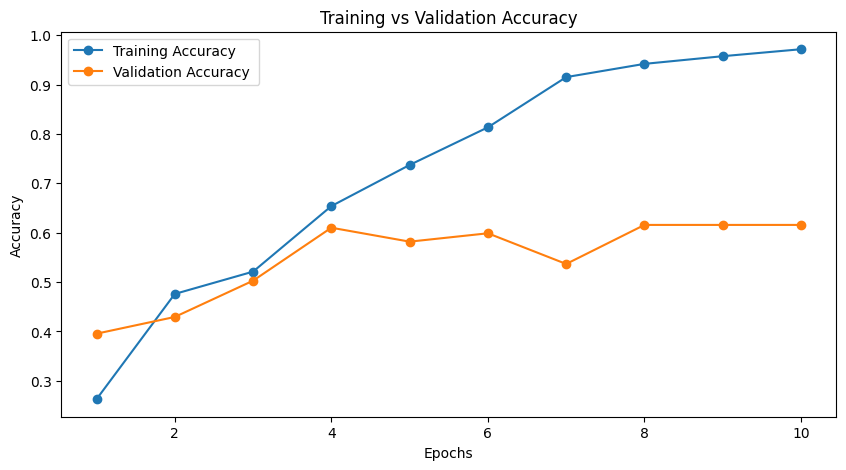

In [26]:
train_accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
epochs=range(1,EPOCH+1)

plt.figure(figsize=(10,5))
plt.plot(epochs,train_accuracy,label='Training Accuracy',marker='o')
plt.plot(epochs,val_accuracy,label='Validation Accuracy ',marker='o')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()